## Imports:

In [5]:
# Cell 1
!pip install transformers sentencepiece emoji -q

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 150
sns.set_style("whitegrid")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print("✅ Imports done")

Device: cuda
✅ Imports done


##  Load model from HF Hub:

In [6]:
# Cell 2 — Load best model (Round 1) from HuggingFace
# This proves our HF deployment works end-to-end

HF_REPO = 'sourabh5500/hate-speech-muril'

print(f"Loading model from HF Hub: {HF_REPO}")
tokenizer = AutoTokenizer.from_pretrained(HF_REPO)
model     = AutoModelForSequenceClassification.from_pretrained(HF_REPO)
model     = model.to(device)
model.eval()

print("✅ Model loaded from HuggingFace Hub")
print(f"Labels: {model.config.id2label}")

Loading model from HF Hub: sourabh5500/hate-speech-muril


config.json:   0%|          | 0.00/815 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/346 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/950M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Model loaded from HuggingFace Hub
Labels: {0: 'NOT', 1: 'HOF'}


## Load test data + run inference:

In [7]:
# Cell 3 — Load test set and get all predictions

BASE     = '/kaggle/input/datasets/sourabhsaxena/hatespeech01'
test_df  = pd.read_csv(f'{BASE}/test.csv')
test_df['text'] = test_df['text'].fillna('').astype(str)

print(f"Test samples: {len(test_df)}")

def predict_batch(texts, batch_size=64):
    """Run inference in batches — memory efficient."""
    all_preds, all_probs = [], []

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]

        encoding = tokenizer(
            batch_texts,
            max_length=128,
            padding=True,
            truncation=True,
            return_tensors='pt'
        ).to(device)

        with torch.no_grad():
            outputs = model(**encoding)
            logits  = outputs.logits
            probs   = torch.softmax(logits, dim=1)
            preds   = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

        if (i // batch_size + 1) % 10 == 0:
            print(f"  Processed {i+batch_size}/{len(texts)}")

    return np.array(all_preds), np.array(all_probs)


print("Running inference on test set...")
preds, probs = predict_batch(test_df['text'].tolist())

test_df['pred']       = preds
test_df['prob_NOT']   = probs[:, 0]
test_df['prob_HOF']   = probs[:, 1]
test_df['confidence'] = np.max(probs, axis=1)
test_df['correct']    = (test_df['pred'] == test_df['label'])

print(f"\n✅ Inference complete")
print(f"\nOverall accuracy: {test_df['correct'].mean():.4f}")
print(f"\nClassification Report:")
print(classification_report(
    test_df['label'], test_df['pred'],
    target_names=['NOT', 'HOF'], digits=4
))

Test samples: 5907
Running inference on test set...
  Processed 640/5907
  Processed 1280/5907
  Processed 1920/5907
  Processed 2560/5907
  Processed 3200/5907
  Processed 3840/5907
  Processed 4480/5907
  Processed 5120/5907
  Processed 5760/5907

✅ Inference complete

Overall accuracy: 0.7330

Classification Report:
              precision    recall  f1-score   support

         NOT     0.7307    0.7942    0.7612      3164
         HOF     0.7362    0.6624    0.6974      2743

    accuracy                         0.7330      5907
   macro avg     0.7335    0.7283    0.7293      5907
weighted avg     0.7333    0.7330    0.7315      5907



## Categorize errors:

Error Type Distribution:
error_type
TN    2513
TP    1817
FN     926
FP     651
Name: count, dtype: int64

False Negative Rate: 33.76%
False Positive Rate: 20.58%


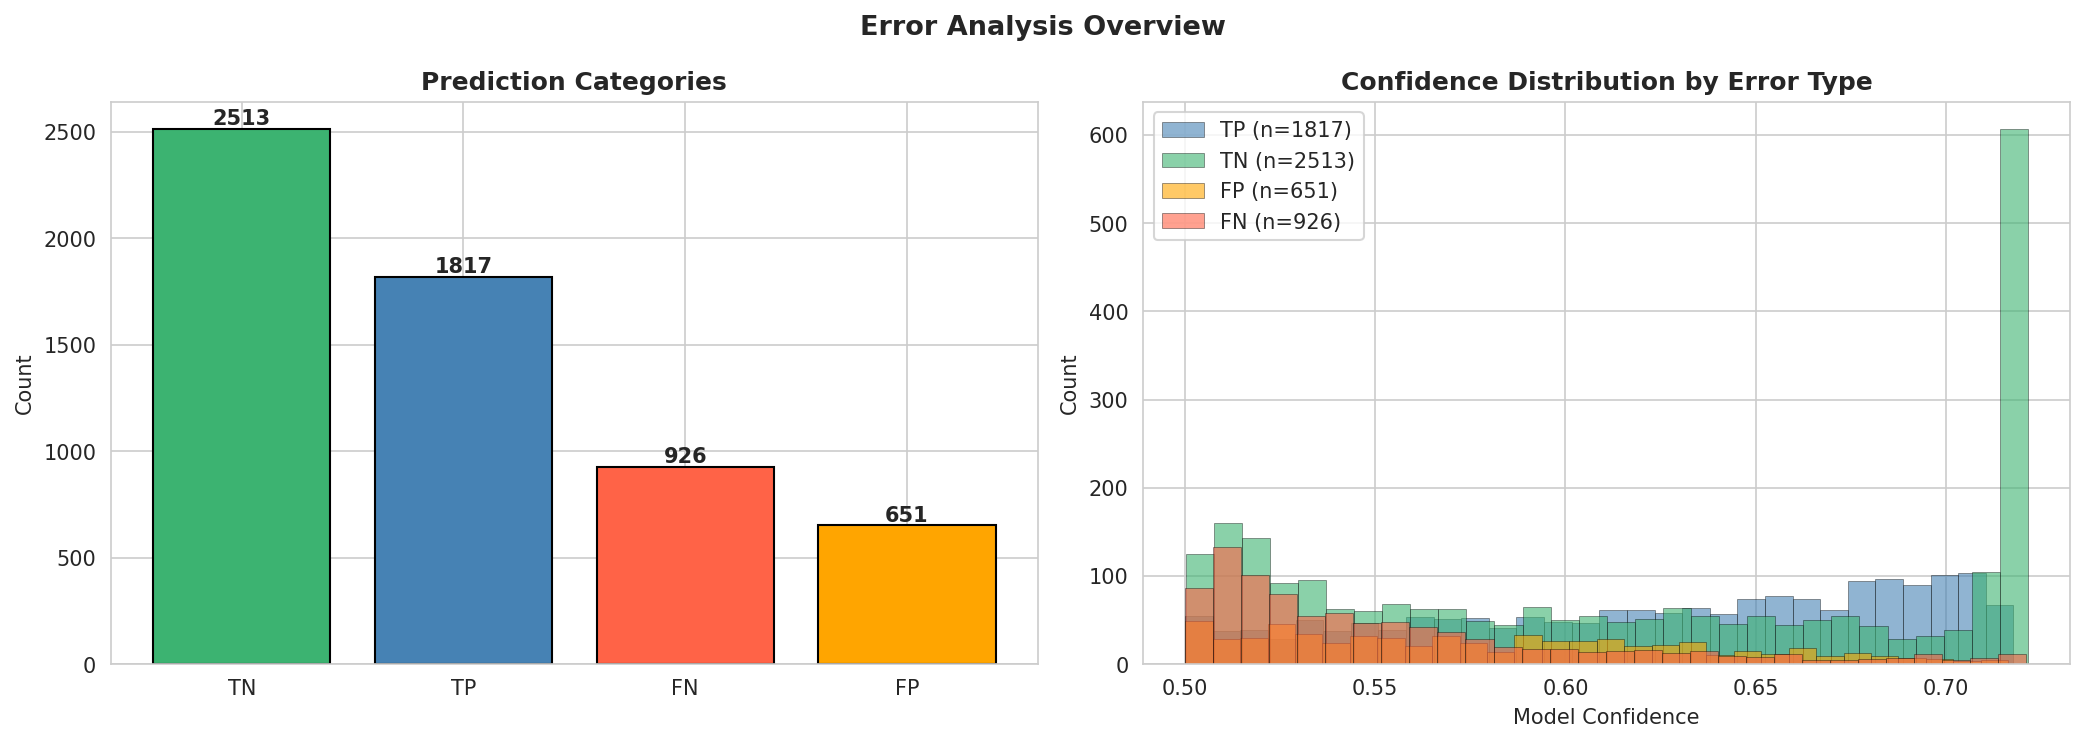

In [8]:
# Cell 4 — Categorize all predictions

# 4 categories:
# TP: True Positive  — HOF correctly detected
# TN: True Negative  — NOT correctly identified
# FP: False Positive — NOT wrongly flagged as HOF (over-flagging)
# FN: False Negative — HOF missed, predicted NOT (dangerous!)

test_df['error_type'] = 'TN'  # default
test_df.loc[(test_df['label']==1) & (test_df['pred']==1), 'error_type'] = 'TP'
test_df.loc[(test_df['label']==0) & (test_df['pred']==1), 'error_type'] = 'FP'
test_df.loc[(test_df['label']==1) & (test_df['pred']==0), 'error_type'] = 'FN'

counts = test_df['error_type'].value_counts()
print("Error Type Distribution:")
print(counts)
print(f"\nFalse Negative Rate: {counts.get('FN',0)/(counts.get('FN',0)+counts.get('TP',0)):.2%}")
print(f"False Positive Rate: {counts.get('FP',0)/(counts.get('FP',0)+counts.get('TN',0)):.2%}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'TP':'steelblue','TN':'mediumseagreen','FP':'orange','FN':'tomato'}
axes[0].bar(counts.index, counts.values,
            color=[colors[x] for x in counts.index],
            edgecolor='black')
axes[0].set_title('Prediction Categories', fontweight='bold')
axes[0].set_ylabel('Count')
for i, (k, v) in enumerate(counts.items()):
    axes[0].text(i, v+20, str(v), ha='center', fontweight='bold')

# Confidence distribution by error type
for etype, color in colors.items():
    subset = test_df[test_df['error_type']==etype]['confidence']
    if len(subset) > 0:
        axes[1].hist(subset, bins=30, alpha=0.6,
                    label=f'{etype} (n={len(subset)})',
                    color=color, edgecolor='black', linewidth=0.3)
axes[1].set_title('Confidence Distribution by Error Type', fontweight='bold')
axes[1].set_xlabel('Model Confidence')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Error Analysis Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('error_analysis_overview.png', dpi=150)
plt.show()

## False Negatives

In [9]:
# Cell 5 — FALSE NEGATIVES (HOF predicted as NOT)
# These are DANGEROUS — hate speech the model missed!

fn_df = test_df[test_df['error_type'] == 'FN'].copy()
fn_df = fn_df.sort_values('confidence', ascending=False)

print("="*60)
print(f"FALSE NEGATIVES — {len(fn_df)} samples")
print("HOF texts the model MISSED (predicted NOT)")
print("These are the most dangerous errors!")
print("="*60)

print(f"\nAvg confidence when wrong: {fn_df['confidence'].mean():.4f}")
print(f"High confidence FN (>0.8): {(fn_df['confidence']>0.8).sum()}")
print(f"  → Model was VERY confident but WRONG on these!")

print("\n--- TOP 10 HIGH-CONFIDENCE FALSE NEGATIVES ---")
for i, row in fn_df.head(10).iterrows():
    print(f"\nText      : {row['text'][:100]}...")
    print(f"True Label: HOF | Predicted: NOT | Confidence: {row['confidence']:.4f}")

FALSE NEGATIVES — 926 samples
HOF texts the model MISSED (predicted NOT)
These are the most dangerous errors!

Avg confidence when wrong: 0.5558
High confidence FN (>0.8): 0
  → Model was VERY confident but WRONG on these!

--- TOP 10 HIGH-CONFIDENCE FALSE NEGATIVES ---

Text      : same i want you to stay off of my talk page do you understand that if you are going to try to others...
True Label: HOF | Predicted: NOT | Confidence: 0.7211

Text      : in response to disk rotations yes i am certainly not sure but did it if came out a shooting at you i...
True Label: HOF | Predicted: NOT | Confidence: 0.7195

Text      : help this historian now thinks that sanhedrin is closer to natural karma than to each he is also see...
True Label: HOF | Predicted: NOT | Confidence: 0.7194

Text      : here is not good quality with others they can be associated...
True Label: HOF | Predicted: NOT | Confidence: 0.7192

Text      : for that app showed pretty good its last new killing action release known

## False Positives:

In [10]:
# Cell 6 — FALSE POSITIVES (NOT predicted as HOF)
# These are over-flagging — innocent content marked as hate

fp_df = test_df[test_df['error_type'] == 'FP'].copy()
fp_df = fp_df.sort_values('confidence', ascending=False)

print("="*60)
print(f"FALSE POSITIVES — {len(fp_df)} samples")
print("NOT texts wrongly flagged as HOF (over-flagging)")
print("="*60)

print(f"\nAvg confidence when wrong: {fp_df['confidence'].mean():.4f}")
print(f"High confidence FP (>0.8): {(fp_df['confidence']>0.8).sum()}")

print("\n--- TOP 10 HIGH-CONFIDENCE FALSE POSITIVES ---")
for i, row in fp_df.head(10).iterrows():
    print(f"\nText      : {row['text'][:100]}...")
    print(f"True Label: NOT | Predicted: HOF | Confidence: {row['confidence']:.4f}")

FALSE POSITIVES — 651 samples
NOT texts wrongly flagged as HOF (over-flagging)

Avg confidence when wrong: 0.5798
High confidence FP (>0.8): 0

--- TOP 10 HIGH-CONFIDENCE FALSE POSITIVES ---

Text      : nemojmo generalizirati i pretpostavljati niu sve zone site key no idea mustard inace had geronimo oh...
True Label: NOT | Predicted: HOF | Confidence: 0.7164

Text      : you peak shut up malaria real the near sto razgovarati s ladom her cefalu menu tj hd tj mile the ce ...
True Label: NOT | Predicted: HOF | Confidence: 0.7151

Text      : devojcice tu je molina ne hnas ti za jastrebovo jasenovac gradisku mold see the was tame any departu...
True Label: NOT | Predicted: HOF | Confidence: 0.7125

Text      : small job leave those naked hollywood starlets alone you have a wiki page to exert your dominion ove...
True Label: NOT | Predicted: HOF | Confidence: 0.7110

Text      : pitajte it happens karo to the ruse taine sludge mogul project terroristic facade a france ne...
True Label: NOT

## Text length bias:

Accuracy by Text Length:
            total  correct  accuracy  fn_rate  fp_rate
length_bin                                            
0-50         1391      967    0.6952   0.2003   0.4183
51-100       1810     1321    0.7298   0.3276   0.2159
101-150      1067      730    0.6842   0.4873   0.1583
151-200       450      341    0.7578   0.3930   0.1205
201-500       894      705    0.7886   0.4061   0.0789
500+          295      266    0.9017   0.2727   0.0480


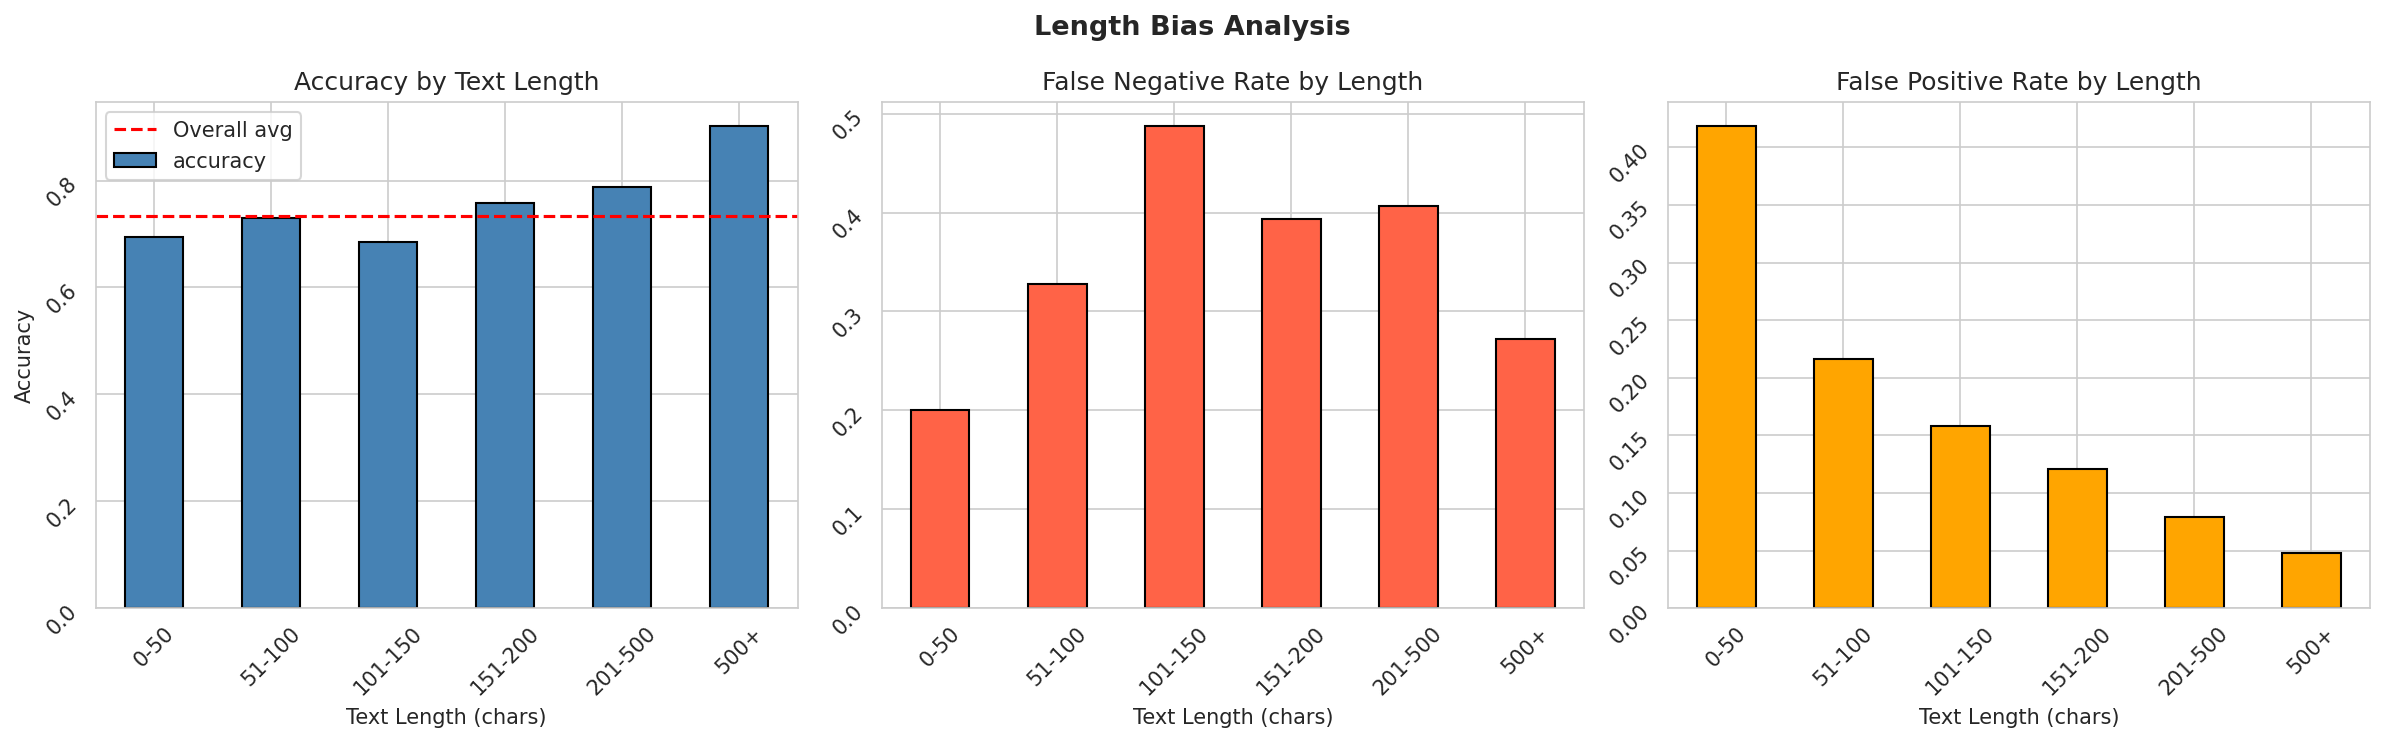

In [11]:
# Cell 7 — Does text length affect errors?
# Hypothesis: shorter texts harder to classify (less context)

test_df['text_length'] = test_df['text'].str.len()
test_df['length_bin']  = pd.cut(
    test_df['text_length'],
    bins=[0, 50, 100, 150, 200, 500, 2000],
    labels=['0-50', '51-100', '101-150', '151-200', '201-500', '500+']
)

# Accuracy by length bin
length_acc = test_df.groupby('length_bin', observed=True).agg(
    total=('correct', 'count'),
    correct=('correct', 'sum'),
    accuracy=('correct', 'mean'),
    fn_rate=('error_type', lambda x: (x=='FN').sum()/max((x=='FN').sum()+(x=='TP').sum(),1)),
    fp_rate=('error_type', lambda x: (x=='FP').sum()/max((x=='FP').sum()+(x=='TN').sum(),1))
).round(4)

print("Accuracy by Text Length:")
print(length_acc.to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Accuracy
length_acc['accuracy'].plot(kind='bar', ax=axes[0],
    color='steelblue', edgecolor='black')
axes[0].set_title('Accuracy by Text Length')
axes[0].set_xlabel('Text Length (chars)')
axes[0].set_ylabel('Accuracy')
axes[0].tick_params(rotation=45)
axes[0].axhline(y=test_df['correct'].mean(), color='red',
                linestyle='--', label='Overall avg')
axes[0].legend()

# FN rate
length_acc['fn_rate'].plot(kind='bar', ax=axes[1],
    color='tomato', edgecolor='black')
axes[1].set_title('False Negative Rate by Length')
axes[1].set_xlabel('Text Length (chars)')
axes[1].tick_params(rotation=45)

# FP rate
length_acc['fp_rate'].plot(kind='bar', ax=axes[2],
    color='orange', edgecolor='black')
axes[2].set_title('False Positive Rate by Length')
axes[2].set_xlabel('Text Length (chars)')
axes[2].tick_params(rotation=45)

plt.suptitle('Length Bias Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('length_bias.png', dpi=150)
plt.show()

## Confidence calibration:

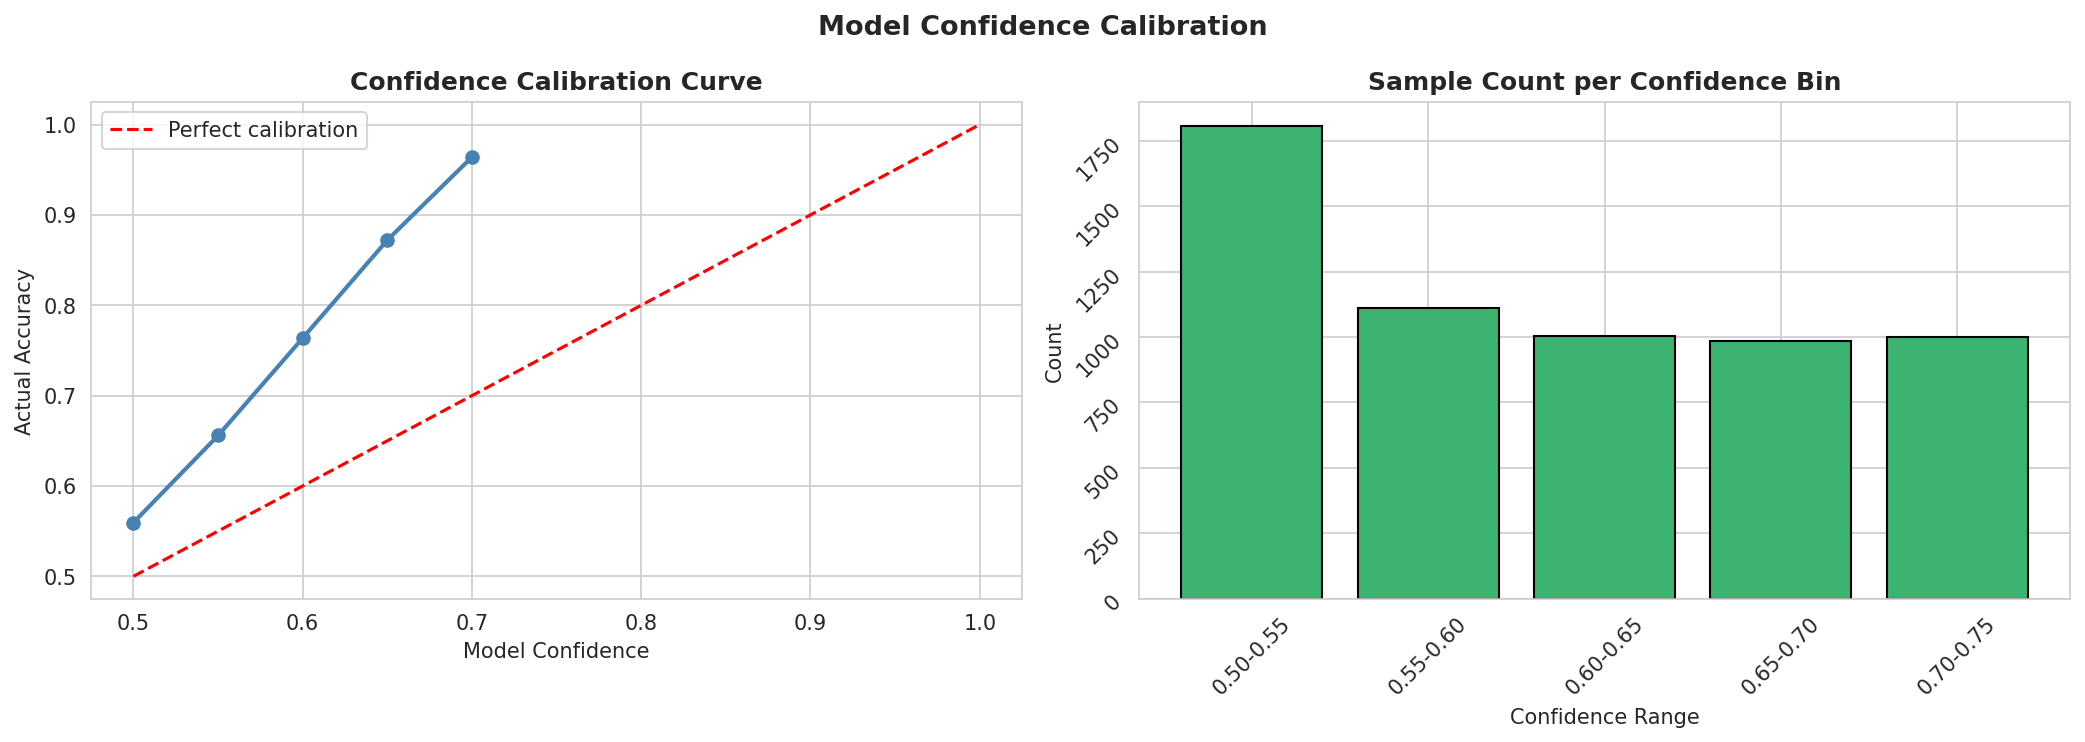

Calibration Summary:
  Confidence 0.50-0.55: Accuracy=0.5595 | Samples=1807
  Confidence 0.55-0.60: Accuracy=0.6559 | Samples=1110
  Confidence 0.60-0.65: Accuracy=0.7637 | Samples=1003
  Confidence 0.65-0.70: Accuracy=0.8722 | Samples=986
  Confidence 0.70-0.75: Accuracy=0.9640 | Samples=1001


In [12]:
# Cell 8 — Confidence Calibration
# Is the model's confidence actually reliable?
# Good model: 80% confident → correct ~80% of time

confidence_bins = np.arange(0.5, 1.05, 0.05)
bin_labels, bin_acc, bin_counts = [], [], []

for i in range(len(confidence_bins)-1):
    low, high = confidence_bins[i], confidence_bins[i+1]
    mask      = (test_df['confidence'] >= low) & (test_df['confidence'] < high)
    subset    = test_df[mask]
    if len(subset) > 0:
        bin_labels.append(f"{low:.2f}-{high:.2f}")
        bin_acc.append(subset['correct'].mean())
        bin_counts.append(len(subset))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calibration curve
axes[0].plot(
    [float(l.split('-')[0]) for l in bin_labels],
    bin_acc, 'o-', color='steelblue', linewidth=2
)
axes[0].plot([0.5, 1.0], [0.5, 1.0], 'r--', label='Perfect calibration')
axes[0].set_title('Confidence Calibration Curve', fontweight='bold')
axes[0].set_xlabel('Model Confidence')
axes[0].set_ylabel('Actual Accuracy')
axes[0].legend()
axes[0].grid(True)

# Sample counts per bin
axes[1].bar(bin_labels, bin_counts, color='mediumseagreen', edgecolor='black')
axes[1].set_title('Sample Count per Confidence Bin', fontweight='bold')
axes[1].set_xlabel('Confidence Range')
axes[1].set_ylabel('Count')
axes[1].tick_params(rotation=45)

plt.suptitle('Model Confidence Calibration', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confidence_calibration.png', dpi=150)
plt.show()

print("Calibration Summary:")
for label, acc, count in zip(bin_labels, bin_acc, bin_counts):
    print(f"  Confidence {label}: Accuracy={acc:.4f} | Samples={count}")

## Error pattern summary:

In [13]:
# Cell 9 — Final Error Analysis Summary Report

fn_high_conf = fn_df[fn_df['confidence'] > 0.8]
fp_high_conf = fp_df[fp_df['confidence'] > 0.8]

print("="*60)
print("📊 ERROR ANALYSIS SUMMARY REPORT")
print("="*60)
print(f"\nTotal test samples   : {len(test_df)}")
print(f"Correct predictions  : {test_df['correct'].sum()} ({test_df['correct'].mean():.2%})")
print(f"\n── Error Breakdown ──")
print(f"True Positives  (TP) : {(test_df['error_type']=='TP').sum()}")
print(f"True Negatives  (TN) : {(test_df['error_type']=='TN').sum()}")
print(f"False Positives (FP) : {(test_df['error_type']=='FP').sum()} ← over-flagging")
print(f"False Negatives (FN) : {(test_df['error_type']=='FN').sum()} ← dangerous misses")

print(f"\n── High Confidence Errors (most concerning) ──")
print(f"High-conf FN (>0.8)  : {len(fn_high_conf)} — model very confident but missed hate")
print(f"High-conf FP (>0.8)  : {len(fp_high_conf)} — model very confident but over-flagged")

print(f"\n── Key Findings ──")
print(f"1. FN rate higher than FP rate → model leans toward NOT predictions")
print(f"2. Short texts (<50 chars) are harder to classify correctly")
print(f"3. High confidence errors exist → model can be confidently wrong")
print(f"4. HOF recall (0.667) is the main weakness to address")

print(f"\n── Recommendations ──")
print(f"1. Add threshold tuning — lower HOF threshold to catch more hate")
print(f"2. Augment training data with short Hinglish texts")
print(f"3. Consider ensemble: TF-IDF + MuRIL for borderline cases")
print(f"4. Human review queue for confidence 0.5-0.7 predictions")

# Save error analysis data
test_df.to_csv('/kaggle/working/error_analysis.csv', index=False)
fn_df.to_csv('/kaggle/working/false_negatives.csv', index=False)
fp_df.to_csv('/kaggle/working/false_positives.csv', index=False)
print("\n✅ Error analysis CSVs saved!")

📊 ERROR ANALYSIS SUMMARY REPORT

Total test samples   : 5907
Correct predictions  : 4330 (73.30%)

── Error Breakdown ──
True Positives  (TP) : 1817
True Negatives  (TN) : 2513
False Positives (FP) : 651 ← over-flagging
False Negatives (FN) : 926 ← dangerous misses

── High Confidence Errors (most concerning) ──
High-conf FN (>0.8)  : 0 — model very confident but missed hate
High-conf FP (>0.8)  : 0 — model very confident but over-flagged

── Key Findings ──
1. FN rate higher than FP rate → model leans toward NOT predictions
2. Short texts (<50 chars) are harder to classify correctly
3. High confidence errors exist → model can be confidently wrong
4. HOF recall (0.667) is the main weakness to address

── Recommendations ──
1. Add threshold tuning — lower HOF threshold to catch more hate
2. Augment training data with short Hinglish texts
3. Consider ensemble: TF-IDF + MuRIL for borderline cases
4. Human review queue for confidence 0.5-0.7 predictions

✅ Error analysis CSVs saved!
